# SQL Murder Mistery

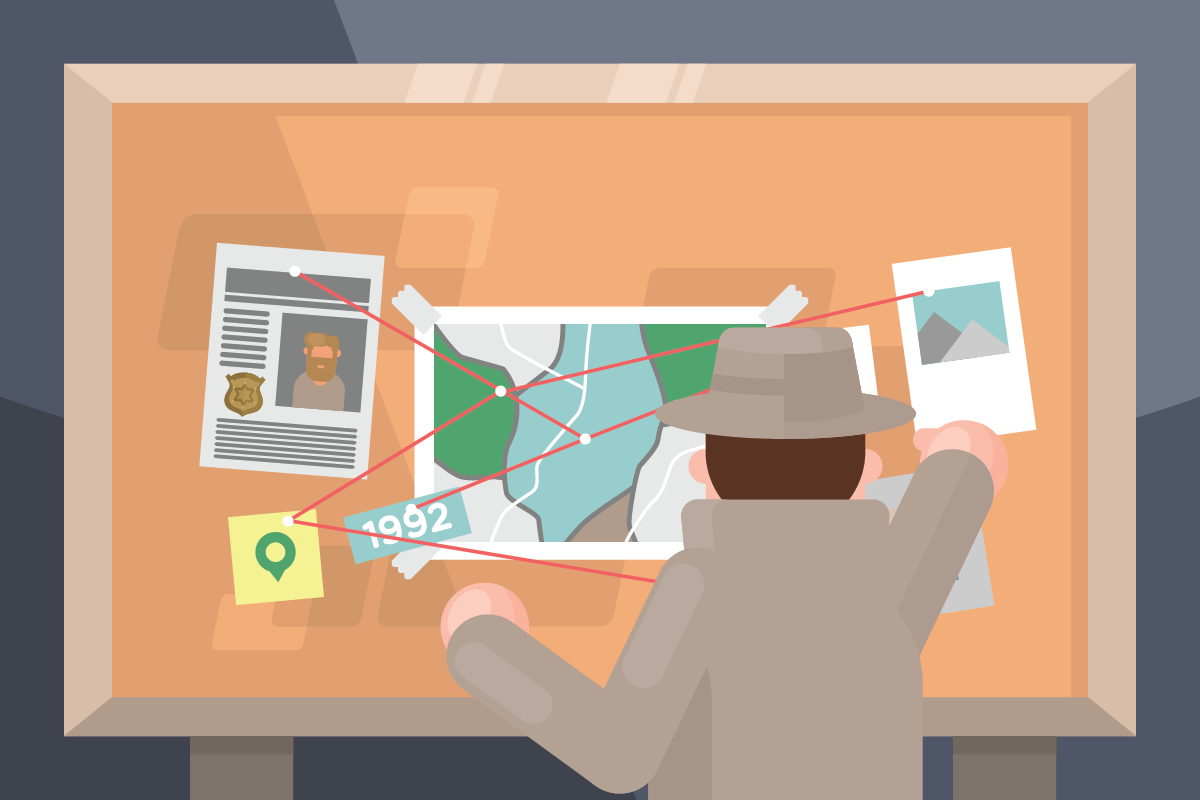

![image-2.png](https://drive.google.com/uc?id=1QxBiB5dMkAkOB0aksGM3yOh1QiBq3He-)

Ha ocurrido un crimen y el detective necesita tu ayuda. El detective te dio el informe de la escena del crimen, pero de alguna manera lo perdiste. Recuerdas vagamente que el crimen fue un **asesinato** que ocurrió en algún momento del **15 de enero de 2018** y que tuvo lugar en **SQL City**. Comienza recuperando el informe de la escena del crimen correspondiente de la base de datos del departamento de policía.
Vamos a trabajar con la Base de datos del fichero: **sql-murder-mystery**

El diagrama de la Base de Datos es el siguiente:

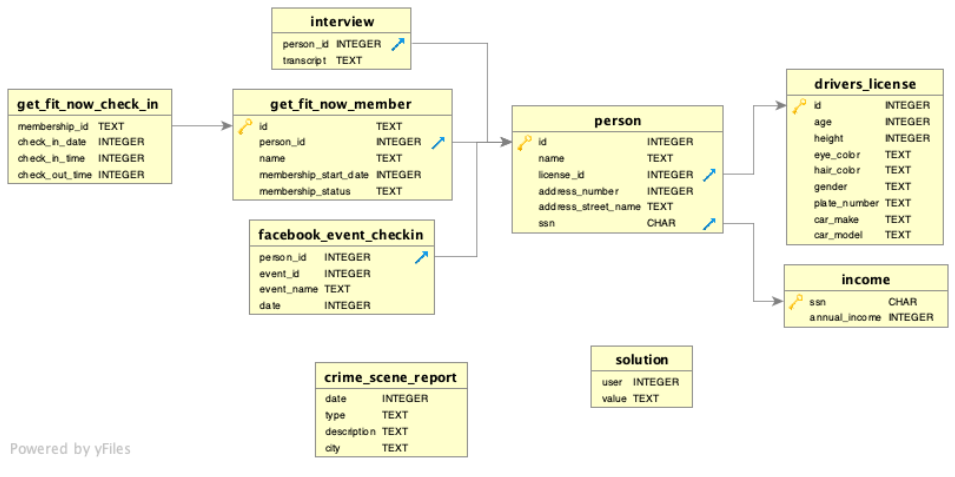

![diagrama](https://drive.google.com/uc?id=1s9oYP4U7nSQL66XnT5KZI17qwlFiGIQm)

### 1. Importamos la Base de Datos

In [1]:
import sqlite3
import pandas as pd
conexion = sqlite3.connect("sql-murder-mystery.db")

def query(sql):
    return pd.read_sql_query(sql, conexion)


### 2. Extraemos los datos de la escena del crimen

In [10]:
query("""SELECT *
FROM crime_scene_report
WHERE date = 20180115
  AND type = 'murder'
  AND city = 'SQL City'
""")

,date,type,description,city
0,20180115,murder,Security footage shows that there were 2 witne...,SQL City


### 3 Datos de los Testigos

En la consulta anterior se dice que se vieron a 2 testigos, uno que vive en la ultima casa de Northwestern Dr y el segundo llamado Annabel en Franklin Ave

In [ ]:
# Primer testigo
query("""SELECT *
FROM person
WHERE address_street_name = 'Northwestern Dr'
ORDER BY address_number DESC
LIMIT 1
""")

,id,name,license_id,address_number,address_street_name,ssn
0,14887,Morty Schapiro,118009,4919,Northwestern Dr,111564949


In [ ]:
# Segundo testigo
query("""
SELECT *
FROM person
WHERE name LIKE 'Annabel%'
AND address_street_name = 'Franklin Ave'
""")

,id,name,license_id,address_number,address_street_name,ssn
0,16371,Annabel Miller,490173,103,Franklin Ave,318771143


### 4. Datos interrogatorios Testigos

In [ ]:
# Declaración de Morty Schapiro
query("""SELECT *
FROM interview
WHERE person_id = 14887
""")

,person_id,transcript
0,14887,I heard a gunshot and then saw a man run out. ...


In [ ]:
# Declaración de Annabel Miller
query("""SELECT *
FROM interview
WHERE person_id = 16371
""")

,person_id,transcript
0,16371,"I saw the murder happen, and I recognized the ..."


### 5. Buscamos a los Sospechosos que nos indican los testigos

Los testigos nos dicen que que el asesino llevaba una bolsa de gimnasio con el numero que empezaba por 48Z, que era miembro Gold, que estuvo en el gimnasio el 9 de enero de 2018 y la matricula de su coche tenia H42W

In [ ]:
query("""SELECT p.name, p.id
FROM person p
JOIN get_fit_now_member m ON p.id = m.person_id
JOIN get_fit_now_check_in c ON m.id = c.membership_id
JOIN drivers_license d ON p.license_id = d.id
WHERE m.id LIKE '48Z%'
AND m.membership_status = 'gold'
AND c.check_in_date = 20180109
AND d.plate_number LIKE '%H42W%'
""")

,name,id
0,Jeremy Bowers,67318


### 6. Veamos qué dijo el sospechoso en el interrogatorio.

* ¿Sabes quien ha cometido el crimen? Analiza su interrogatorio.

* ¿Tienes los nombres de todos los responsables?

In [ ]:
query("""SELECT *
FROM interview
WHERE person_id = (SELECT id FROM person WHERE name = 'Jeremy Bowers')
""")

,person_id,transcript
0,67318,I was hired by a woman with a lot of money. I ...


### 7. Encuentra al Verdadero Culpable

**Jummmmmmm qué está pasando aquí!!**

Busca al verdadero culpable utilizando una única sentencia SELECT o utiliza funciones de orden superior para filtrar los datos.

El asesino nos dice que le contrato una mujer, muy rica, de unos 65 kilos, con el pelo rojo, su coche es un Tesla Model S, estuvo 3 veces en el evento de SQL Symphony Concert en diciembre de 2017

In [ ]:
query("""SELECT p.name
FROM person p
JOIN drivers_license d ON p.license_id = d.id
JOIN income i ON p.ssn = i.ssn
JOIN facebook_event_checkin f ON p.id = f.person_id
WHERE d.gender = 'female'
AND d.hair_color = 'red'
AND d.car_make = 'Tesla'
AND d.car_model = 'Model S'
AND d.height BETWEEN 60 AND 70
AND f.event_name = 'SQL Symphony Concert'
AND f.date LIKE '201712%'
GROUP BY p.id
HAVING COUNT(f.event_id) = 3
""")

,name
0,Miranda Priestly


## 8. Haz tus Detenciones

* Pon aquí el resultado de tus investigaciones y quien/es deberían ser enchironados. Aporta todos los datos que consideres necesarios.


Los responsables del asesinato serian, Jeremy Bower (asesino) y Miranda Priesty (que contrato a Jeremy)